In [1]:
# cell 1 - install and imports of required libraries
import torch
import torch_geometric
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torch_geometric.datasets import QM9
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

import random
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import deque
from collections import defaultdict
from collections import Counter

print(f"torch: {torch.__version__}")
print(f"torch_geometric: {torch_geometric.__version__}")
print(f"cuda available: {torch.cuda.is_available()}")
print(torch.cuda.get_device_name()) # confirm GPU visible
x = torch.tensor([1.0]).cuda() # smoke test — no error verification
print("cuda ok")

torch: 2.3.1+cu121
torch_geometric: 2.5.3
cuda available: True
Tesla P100-PCIE-16GB
cuda ok


In [2]:
# cell 2 - load qm9; first run downloads ~130mb to ./data/QM9
dataset = QM9(root='./data/QM9')
print(f"num graphs: {len(dataset)}")
print(f"num node features: {dataset.num_node_features}") # displays the number of attributes per atom (node) to understand the input dimensionality
print(f"num edge features: {dataset.num_edge_features}") # displays the number of attributes per chemical bond (edge) to check available connectivity data
print(f"num targets: {dataset.num_classes}") # must report 19

Extracting data/QM9/raw/qm9_v3.zip
Processing...
Using a pre-processed version of the dataset. Please install 'rdkit' to alternatively process the raw data.


num graphs: 130831
num node features: 11
num edge features: 4
num targets: 19


Done!


In [3]:
# cell 3 - inspect a single molecule; verify your tensor shapes
mol = dataset[0]
print(mol) # pyg summary
print(f"\nx shape: {mol.x.shape}") # [N, 11]
print(f"edge_index shape: {mol.edge_index.shape}") # [2, 2E]
print(f"edge_attr shape: {mol.edge_attr.shape}") # [2E, 4]
print(f"y shape: {mol.y.shape}") # [1, 19]
print(f"num atoms (N): {mol.num_nodes}") # [1, 19]
print(f"num directed edges (2E): {mol.edge_index.shape[1]}")

Data(x=[5, 11], edge_index=[2, 8], edge_attr=[8, 4], y=[1, 19], pos=[5, 3], idx=[1], name='gdb_1', z=[5])

x shape: torch.Size([5, 11])
edge_index shape: torch.Size([2, 8])
edge_attr shape: torch.Size([8, 4])
y shape: torch.Size([1, 19])
num atoms (N): 5
num directed edges (2E): 8


In [4]:
# cell 4 - isoloate u_0 (index 7, internal energy at 0k, in eV)
# this is our prediction target for the full project
TARGET_IDX = 7
TARGET_NAME = 'U0 (internal energy at 0K)'

u0_all = torch.stack([g.y[0, TARGET_IDX] for g in dataset])
print(f"target: {TARGET_NAME}")
print(f"mean: {u0_all.mean():.4f} eV")
print(f"std: {u0_all.std():.4f} eV")
print(f"min: {u0_all.min():.4f} eV")
print(f"max: {u0_all.max():.4f} eV")

target: U0 (internal energy at 0K)
mean: -11178.9668 eV
std: 1085.5787 eV
min: -19444.3867 eV
max: -1101.4878 eV


In [5]:
# cell 5 - inspect node features for molecule 0
# qm9 encodes atoms as 11-dim one-hot + chemical features
# columns: [H, C, N, O, F, atomic_num, aromatic, Hx1, Hx2, Hx3, Hx4]
print("node feature matrix x (first molecule):")
print(mol.x)
print(f"\nshape: {mol.x.shape} -> {mol.num_nodes} atoms x 11 features")

node feature matrix x (first molecule):
tensor([[0., 1., 0., 0., 0., 6., 0., 0., 0., 0., 4.],
        [1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]])

shape: torch.Size([5, 11]) -> 5 atoms x 11 features


In [6]:
# cell 6 - inspect edge structure; confirm bidirectionality
ei = mol.edge_index
print("edge_index (COO):")
print(ei)

print(f"\nshape: {ei.shape}")
print(f"edges are bidirectional: {ei.shape[1] % 2 == 0}") # this must be "True"

# verify: every (u, v) has a corresponding (v, u)
edges = set(zip(ei[0].tolist(), ei[1].tolist()))
reverse_edges = {(v, u) for u, v in edges}
print(f"all reverses present: {edges == reverse_edges}")

edge_index (COO):
tensor([[0, 0, 0, 0, 1, 2, 3, 4],
        [1, 2, 3, 4, 0, 0, 0, 0]])

shape: torch.Size([2, 8])
edges are bidirectional: True
all reverses present: True


In [7]:
# cell 7 - size distribution across dataset
node_counts = torch.tensor([g.num_nodes for g in dataset], dtype=torch.float)
edge_counts = torch.tensor([g.edge_index.shape[1] for g in dataset], dtype=torch.float)

print(f"atoms per molecule - mean: {node_counts.mean():.1f}, "
      f"max: {node_counts.max():.0f}, min: {node_counts.min():.0f}")
print(f"directed edges/mol - mean: {edge_counts.mean():.1f}, "
      f"max: {edge_counts.max():.0f}, min: {edge_counts.min():.0f}")

atoms per molecule - mean: 18.0, max: 29, min: 3
directed edges/mol - mean: 37.3, max: 56, min: 4


In [8]:
# cell 8 - pick a more interesting molecule than methane
# find a molecule with ~10 atoms for a readable spectrum
for i, g in enumerate(dataset):
    if g.num_nodes == 10:
        mol2 = g
        mol2_idx = i
        break

print(f"molecule index: {mol2_idx}")
print(f"name: {mol2.name}")
print(f"num atoms (N): {mol2.num_nodes}")
print(f"num directed edges (2E): {mol2.edge_index.shape[1]}")
print(f"num undirected edges (E): {mol2.edge_index.shape[1] // 2}")

molecule index: 17
name: gdb_18
num atoms (N): 10
num directed edges (2E): 18
num undirected edges (E): 9


In [9]:
# cell 9 - build node feature matrix X and adjacency matrix A explicitly
N = mol2.num_nodes
X = mol2.x # [N, 11] - already a dense matrix
edge_index = mol2.edge_index # [2, 2E]

# build dense adjacency matrix from COO edge_index
A = torch.zeros(N, N)
A[edge_index[0], edge_index[1]] = 1.0

print(f"X shape: {X.shape}")
print(f"A shape: {A.shape}")
print(f"\nadjancency matrix A:")
print(A)
print(f"\nsymmetric: {torch.allclose(A, A.T)}") # must be True
print(f"no self-loops: {A.diagonal().sum().item() == 0}") # must be True

X shape: torch.Size([10, 11])
A shape: torch.Size([10, 10])

adjancency matrix A:
tensor([[0., 1., 0., 0., 1., 1., 1., 0., 0., 0.],
        [1., 0., 1., 1., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 1., 1., 1.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]])

symmetric: True
no self-loops: True


In [10]:
# cell 10 - build degree matrix D and Laplacian L = D - A
degrees = A.sum(dim=1) # [N] - row sums of A
D = torch.diag(degrees) # [N, N] diagonal matrix
L = D - A # graph laplacian

print(f"D diagonal (node degrees): {degrees}")
print(f"\nL shape: {L.shape}")
print(f"\nlaplacian L:")
print(L.round(decimals=1))

# verify: L * 1 = 0
ones = torch.ones(N)
residual = (L @ ones).abs().max().item()
print(f"\nmax |L.1|: {residual:.2e}") # must be ~0

D diagonal (node degrees): tensor([4., 3., 4., 1., 1., 1., 1., 1., 1., 1.])

L shape: torch.Size([10, 10])

laplacian L:
tensor([[ 4., -1.,  0.,  0., -1., -1., -1.,  0.,  0.,  0.],
        [-1.,  3., -1., -1.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0., -1.,  4.,  0.,  0.,  0.,  0., -1., -1., -1.],
        [ 0., -1.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.],
        [-1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.],
        [-1.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.],
        [-1.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.],
        [ 0.,  0., -1.,  0.,  0.,  0.,  0.,  1.,  0.,  0.],
        [ 0.,  0., -1.,  0.,  0.,  0.,  0.,  0.,  1.,  0.],
        [ 0.,  0., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]])

max |L.1|: 0.00e+00


In [11]:
# cell 11 - verify L = B.(B^T) explicitly
# build signed incidence matrix B ∈ R^{N x E} for undirected edges
src, dst = edge_index[0], edge_index[1]

# keep ony one direction per edge (upper triangle of A)
mask = src < dst
src_u = src[mask]
dst_u = dst[mask]

e_u = src_u.shape[0] # number of undirected edges

B = torch.zeros(N, e_u)
for e, (i, j) in enumerate(zip(src_u.tolist(), dst_u.tolist())):
    B[i, e] = +1.0
    B[j, e] = -1.0

L_from_B = B @ B.T

print(f"B shape: {B.shape} -> {N} nodes x {e_u} undirected edges")
print(f"\nmax |L - B.(B^T)|: {(L - L_from_B).abs().max().item():.2e}") # must be ~0

B shape: torch.Size([10, 9]) -> 10 nodes x 9 undirected edges

max |L - B.(B^T)|: 0.00e+00


In [12]:
# cell 12 - compute eigenspectrum of L
# L is real symmetric -> eigenvalues are real and non-negative
eigenvalues, eigenvectors = torch.linalg.eigh(L) # eigh exploits symmetry

print(f"eigen values: ")
for k, lam in enumerate(eigenvalues):
    print(f" lambda_k = {lam.item():.6f}")

print(f"\nlambda_0 = 0 {eigenvalues[0].abs().item() < 1e-5}")
print(f"all lambda >= 0 {(eigenvalues >= -1e-6).all().item()}") # L is PSD
print(f"\nFiedler value lambda_1: {eigenvalues[1].item():.6f}")
print(f"Fiedler vector: {eigenvectors[:, 1].numpy().round(3)}")

eigen values: 
 lambda_k = -0.000000
 lambda_k = 0.208712
 lambda_k = 0.638531
 lambda_k = 0.999999
 lambda_k = 1.000000
 lambda_k = 1.000000
 lambda_k = 1.000000
 lambda_k = 2.832551
 lambda_k = 4.791288
 lambda_k = 5.528918

lambda_0 = 0 True
all lambda >= 0 True

Fiedler value lambda_1: 0.208712
Fiedler vector: [-0.294  0.     0.294  0.    -0.371 -0.371 -0.371  0.371  0.371  0.371]


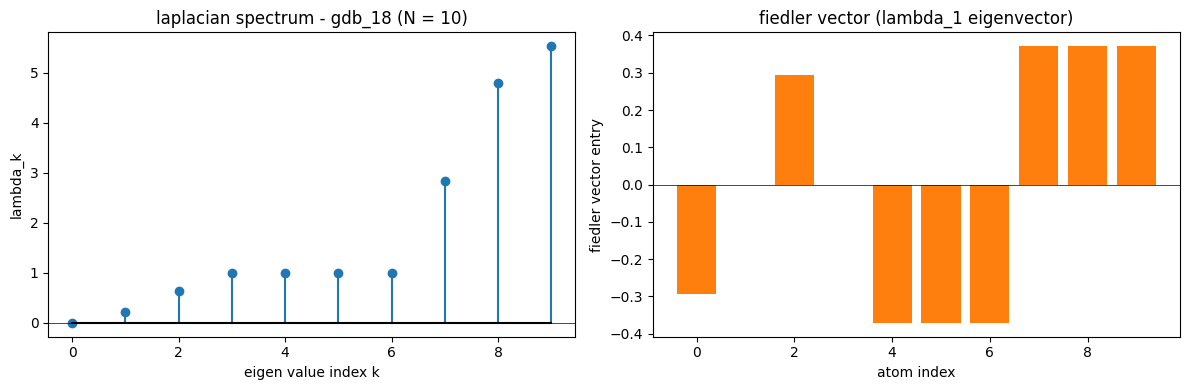

saved: laplacian_spectrum.png


In [13]:
# cell 13 - visualize the eigenspectrum
lam = eigenvalues.numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# spectrum plot
axes[0].stem(range(N), lam, markerfmt='C0o', linefmt='C0-', basefmt='k-')
axes[0].set_xlabel("eigen value index k")
axes[0].set_ylabel("lambda_k")
axes[0].set_title(f"laplacian spectrum - {mol2.name} (N = {N})")
axes[0].axhline(0, color='k', linewidth=0.5)

# fiedler vector (lambda_1 eigenvector) - encodes graph connectivity
fiedler = eigenvectors[:, 1].numpy()
axes[1].bar(range(N), fiedler, color='C1')
axes[1].set_xlabel("atom index")
axes[1].set_ylabel("fiedler vector entry")
axes[1].set_title("fiedler vector (lambda_1 eigenvector)")
axes[1].axhline(0, color='k', linewidth=0.5)

plt.tight_layout()
plt.savefig("laplacian_spectrum.png", dpi=300)
plt.show()
print("saved: laplacian_spectrum.png")

In [14]:
# cell 14 - select 5 molecules of varying size for embedding
target_sizes = [7, 10, 13, 16, 19]
selected = []
for g in dataset:
    if g.num_nodes in target_sizes and not any(s.num_nodes == g.num_nodes for s in selected):
        selected.append(g)
        if len(selected) == 5:
            break

for g in selected:
    print(f"{g.name:12s}\tN={g.num_nodes}\tedges={g.edge_index.shape[1]//2}")

gdb_9       	N=7	edges=6
gdb_18      	N=10	edges=9
gdb_63      	N=13	edges=12
gdb_219     	N=16	edges=15
gdb_1082    	N=19	edges=18


In [15]:
# cell 15 - function: compute laplacian eigenmap embedding for one molecule
def laplacian_eigenmap(g, k=2):
    """
    embed molecule g into R^k using k smallest non-trivial
    eigenvectors of the graph laplacian (discards lambda_0 = 0).
    returns: embedding [N, k], eigenvalues [N]
    """
    N = g.num_nodes
    ei = g.edge_index

    # build adjacency and laplacian
    A = torch.zeros(N, N)
    A[ei[0], ei[1]] = 1.0
    D = torch.diag(A.sum(dim=1))
    L = D - A

    # eigdecomposition - eigh guarantees real, sorted eigenvalues
    eigenvalues, eigenvectors = torch.linalg.eigh(L)
    
    # discard eigenvector 0 (constant), take next k
    embedding = eigenvectors[:, 1:k+1] # [N, k]
    
    return embedding.numpy(), eigenvalues.numpy()

# verify on one molecule
emb, lam = laplacian_eigenmap(selected[0])
print(f"embedding shape: {emb.shape} <- [N, 2]")
print(f"eigenvalues: {lam.round(3)}")
print(f"fiedler (lambda_1): {lam[1]:.4f}")

embedding shape: (7, 2) <- [N, 2]
eigenvalues: [0.    0.296 1.    1.    1.491 3.117 5.097]
fiedler (lambda_1): 0.2955


In [16]:
# cell 16 - decode atom types for coloring the embedding
def get_atom_types(g):
    """
    extract atom type from one-hot prefix of qm9 node features.
    columns 0-4: [H, C, N, O, F]
    returns list of element symbols, length N
    """
    symbols = ['H', 'C', 'N', 'O', 'F']
    one_hot = g.x[:, :5] # [N, 5]
    indices = one_hot.argmax(dim=1).tolist()
    return [symbols[i] for i in indices]

print(get_atom_types(selected[0]))

['C', 'C', 'C', 'H', 'H', 'H', 'H']


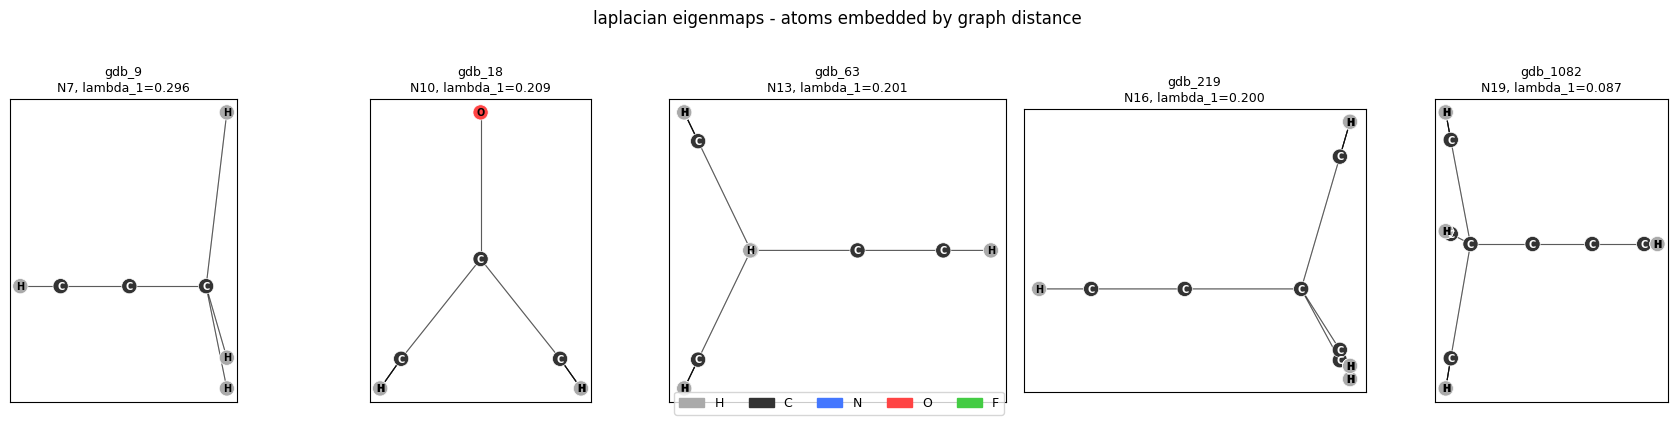

In [17]:
# cell 17 - visualize eigenmaps for all 5 molecules
color_map = {'H': '#aaaaaa', 'C': '#333333', 'N': '#4477ff', 'O': '#ff4444', 'F': '#44cc44'}

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, g in zip(axes, selected):
    emb, lam = laplacian_eigenmap(g, k=2)
    atoms = get_atom_types(g)
    colors = [color_map[a] for a in atoms]

    # draw edges first
    ei = g.edge_index.numpy()
    for e in range(ei.shape[1]):
        i, j = ei[0, e], ei[1, e]
        ax.plot([emb[i, 0], emb[j, 0]], 
                [emb[i, 1], emb[j, 1]], 
                'k-', linewidth=0.8, alpha=0.4, zorder=1)
    
    # draw atoms
    ax.scatter(emb[:, 0], emb[:, 1], c=colors, s=120, zorder=2, edgecolors='white', linewidths=0.5)

    # label atoms
    for idx, (x, y, sym) in enumerate(zip(emb[:, 0], emb[:, 1], atoms)):
        ax.annotate(sym, (x, y), fontsize=7, ha='center', va='center',
                    color='white' if sym == 'C' else 'black', fontweight='bold')
    
    ax.set_title(f"{g.name}\nN{g.num_nodes}, lambda_1={lam[1]:.3f}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_aspect('equal')

# legend
patches = [mpatches.Patch(color=v, label=k) for k, v in color_map.items()]
fig.legend(handles=patches, loc='lower center', ncol=5, fontsize=9)
plt.suptitle("laplacian eigenmaps - atoms embedded by graph distance", y=1.02)
plt.tight_layout()
plt.savefig("eigenmaps.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
# cell 18 - verify the "closeness" guarantee quantitatively
# graph distance vs embedding distance should be correlated
def bfs_distances(g, source):
    """shortest-path distance from shource node via bfs"""
    N = g.num_nodes
    adj = [[] for _ in range(N)]
    ei = g.edge_index.numpy()
    for i, j in zip(ei[0], ei[1]):
        adj[i].append(j)
    
    dist = [-1] * N
    dist[source] = 0
    q = deque([source])
    while q:
        u = q.popleft()
        for v in adj[u]:
            if dist[v] == -1:
                dist[v] = dist[u] + 1
                q.append(v)

    return dist

g = selected[2] # mid-size molecule
emb, _ = laplacian_eigenmap(g, k=2)
N = g.num_nodes

graph_dists, embed_dists = [], []
for src in range(N):
    bd = bfs_distances(g, src)
    for tgt in range(src+1, N):
        graph_dists.append(bd[tgt])
        embed_dists.append(np.linalg.norm(emb[src] - emb[tgt]))

corr = np.corrcoef(graph_dists, embed_dists)[0, 1]
print(f"molecule: {g.name}\tN={N}")
print(f"pearson correlation (graph dist vs embed dist): {corr:.4f}")
print(f"\ninterpretation: {'strong' if corr > 0.6 else 'moderate'} alignment")

molecule: gdb_63	N=13
pearson correlation (graph dist vs embed dist): 0.8779

interpretation: strong alignment


In [19]:
# cell 19 - mpnn message passing layer (no pyg MessagePassing base)
class MPNNLayer(nn.Module):
    """
    one round of message passing:
        m_ij = linear(concat(h_i, h_j, e_ij))
        M_i = sum_{j in N(i)} m_ij
        h_i' = relu(linear(concat(h_i, M_i)))
    """
    def __init__(self, node_dim, edge_dim, hidden_dim):
        super().__init__()
        # message: takes sender, receiver, edge features
        self.msg_mlp = nn.Sequential(
            nn.Linear(node_dim * 2 + edge_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        # update: takes current node state + aggregated messages
        self.update_mlp = nn.Sequential(
            nn.Linear(node_dim + hidden_dim, hidden_dim),
            nn.ReLU(),
        )

    def forward(self, h, edge_index, edge_attr):
        """
        h: [N, node_dim]
        edge_index: [2, 2E]
        edge_attr: [2, 2E]
        return h': [N, hidden_dim]
        """
        src, dst = edge_index[0], edge_index[1] # each directed edge i -> j

        # step 1 - compute messages for every directed edge
        msg_input = torch.cat([h[src], h[dst], edge_attr], dim=-1) # [2E, 2*node_dim + edge_dim]
        messages = self.msg_mlp(msg_input) # [2E, hidden_dim]

        # step 2 - aggregate (sum) messages per destination node
        N = h.shape[0]
        agg = torch.zeros(N, messages.shape[-1], device=h.device)
        agg.scatter_add_(0, dst.unsqueeze(-1).expand_as(messages), messages) # [N, hidden_dim]

        # step 3 - update node states
        h_new = self.update_mlp(torch.cat([h, agg], dim=-1)) # [N, hidden_dim]
        return h_new

In [20]:
# cell 20 - full mpnn model: stack layers + readout + predict
class MPNN(nn.Module):
    """
    spatial mpnn for graph-level regression.
    node_dim -> hidden_dim (via input projection)
    L rounds of message passing
    global mean pool -> mlp -> scalar output
    """
    def __init__(self, node_dim, edge_dim, hidden_dim=64, num_layers=3):
        super().__init__()
        self.input_proj = nn.Linear(node_dim, hidden_dim)
        
        self.layers = nn.ModuleList([MPNNLayer(hidden_dim, edge_dim, hidden_dim) for _ in range(num_layers)])
        self.readout = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x, edge_index, edge_attr, batch):
        """
        x: [N_total, node_dim]
        edge_index: [2, E_total]
        edge_attr: [E_total, edge_dim]
        batch: [N_total] - graph index per node
        returns: [B, 1] scalar per graph
        """
        h = F.relu(self.input_proj(x)) # [N, hidden_dim]

        for layer in self.layers:
            h = layer(h, edge_index, edge_attr) # [N, hidden_dim]

        # global mean pool - permutation invariant readout
        num_graphs = batch.max().item() + 1
        out = torch.zeros(num_graphs, h.shape[-1], device=h.device)
        count = torch.zeros(num_graphs, 1, device=h.device)
        out.scatter_add_(0, batch.unsqueeze(-1).expand_as(h), h)
        count.scatter_add_(0, batch.unsqueeze(-1), torch.ones(h.shape[0], 1, device=h.device))
        graph_emb = out/count # [B, hidden_dim]

        return self.readout(graph_emb) # [B, 1]

In [21]:
# cell 21 - smoke test: single molecule forward pass
torch.manual_seed(42)

mol = dataset[17]
model = MPNN(node_dim=11, edge_dim=4, hidden_dim=64, num_layers=3)
model.eval()

with torch.no_grad():
    pred = model(
        x = mol.x,
        edge_index = mol.edge_index,
        edge_attr = mol.edge_attr,
        batch = torch.zeros(mol.num_nodes, dtype=torch.long), # single graph -> all 0s
    )

print(f"input nodes: {mol.x.shape}")
print(f"input edges: {mol.edge_index.shape}")
print(f"output shape: {pred.shape} <- must be [1, 1]")
print(f"output value: {pred.item():.6f}")

input nodes: torch.Size([10, 11])
input edges: torch.Size([2, 18])
output shape: torch.Size([1, 1]) <- must be [1, 1]
output value: -0.015586


In [22]:
# cell 22 - batch forward pass: verify shapes with a 4-graph batch
loader = DataLoader(dataset[:4], batch_size=4)
batch = next(iter(loader))

with torch.no_grad():
    preds = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)

print(f"batch.num_graphs: {batch.num_graphs}")
print(f"batch.x shape: {batch.x.shape} <- all nodes stacked")
print(f"batch.batch: {batch.batch}") # node -> graph assignment
print(f"preds shape: {preds.shape} <- must be [4, 1]")

batch.num_graphs: 4
batch.x shape: torch.Size([16, 11]) <- all nodes stacked
batch.batch: tensor([0, 0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 3, 3, 3, 3])
preds shape: torch.Size([4, 1]) <- must be [4, 1]


In [23]:
# cell 23 - construct a random permutation of molecule 17
torch.manual_seed(0)

mol = dataset[17]
N = mol.num_nodes
pi = torch.randperm(N) # random permutation of [0, ..., N-1]
pi_inv = torch.argsort(pi) # inverse permutation (for reference)

print(f"permutation pi: {pi.tolist()}")
print(f"inverse pi^(-1): {pi_inv.tolist()}")

# permute node features
x_perm = mol.x[pi] # rows reordered by pi

# remap edge indices: old node id i -> new node id pi[i]
edge_index_perm = pi[mol.edge_index] # broadcast pi as lookup over [2, 2E]

print(f"\noriginal edge_index (first 5 cols):\n{mol.edge_index[:, :5]}")
print(f"\npermuted edge_index (first 5 cols):\n{edge_index_perm[:, :5]}")

permutation pi: [4, 1, 7, 5, 3, 9, 0, 8, 6, 2]
inverse pi^(-1): [6, 1, 9, 4, 0, 3, 8, 2, 7, 5]

original edge_index (first 5 cols):
tensor([[0, 0, 0, 0, 1],
        [1, 4, 5, 6, 0]])

permuted edge_index (first 5 cols):
tensor([[4, 4, 4, 4, 1],
        [1, 3, 9, 0, 4]])


In [24]:
# cell 24 - verify graph structure is preserved under permutation
# check: adjacency matrices are permuted versions of each other

A_orig = torch.zeros(N, N)
A_orig[mol.edge_index[0], mol.edge_index[1]] = 1.0

A_perm = torch.zeros(N, N)
A_perm[edge_index_perm[0], edge_index_perm[1]] =1.0

# P A P^T should equal A_perm
P = torch.zeros(N, N)
P[pi, torch.arange(N)] = 1.0 # permutation matrix

A_check = P @ A_orig @ P.T

print(f"max |P.A.P^T - A_perm|: {(A_check - A_perm).abs().max().item():.2e} <- must be 0")
print("\ngraph structure preserved under permutation" if (A_check - A_perm).abs().max() < 1e-6 else "FAIL")

max |P.A.P^T - A_perm|: 0.00e+00 <- must be 0

graph structure preserved under permutation


In [25]:
# cell 25 - the equivariance test: both orderings must produce idential output and test corrected with fp
model.eval()
batch_orig = torch.zeros(N, dtype=torch.long)

with torch.no_grad():
    out_orig = model(mol.x, mol.edge_index, mol.edge_attr, batch_orig)
    out_perm = model(x_perm, edge_index_perm, mol.edge_attr, batch_orig)

diff = (out_orig - out_perm).abs().item()
print(f"original ordering output: {out_orig.item():.8f}")
print(f"permuted ordering output: {out_perm.item():.8f}")
print(f"absolute different: {(out_orig - out_perm).abs().item():.2e}")

# fp32 scatter_add_ is non-associative — tolerance reflects accumulation error
print(f"\nequivariance test (tol=1e-3): {'PASS' if diff < 1e-3 else 'FAIL'}")

original ordering output: -0.01558634
permuted ordering output: -0.01602823
absolute different: 4.42e-04

equivariance test (tol=1e-3): PASS


In [26]:
# cell 26 - stress test: 100 random permutations and test corrected with fp32 tolerance
max_diff = 0.0
for seed in range(100):
    torch.manual_seed(seed)
    pi = torch.randperm(N)
    x_p = mol.x[pi]
    ei_p = pi[mol.edge_index]
    with torch.no_grad():
        diff = (model(mol.x, mol.edge_index, mol.edge_attr, batch_orig) - model(x_p, ei_p, mol.edge_attr, batch_orig)).abs().item()
    max_diff = max(max_diff, diff)

print(f"max |out_orig - out_perm| over 100 permutations: {max_diff:.2e}")
print(f"\nstress test (tol=1e-3): {'PASS' if max_diff < 1e-3 else 'FAIL'}")

max |out_orig - out_perm| over 100 permutations: 4.47e-04

stress test (tol=1e-3): PASS


In [27]:
# cell 27 - chebnet convolution layer from scratch
class ChebConv(nn.Module):
    """
    chebyshev spectral graph convolution.
    filter: sum_{k=0}^{K-1} theta_k * T_k(L_tilde) x
    where L_tilde = 2L/lambda_max - I (spectrum in [-1, 1])
    uses the recurrence: T_0=I, T_1=L_tilde, T_k=2*L_tilde*T_k{k-1} - T_{k-2}
    """
    def __init__(self, in_dim, out_dim, K=3):
        super().__init__()
        self.K = K
        # one linear weight per polynomial order, applied to concatenated T_k x
        self.linear = nn.Linear(K * in_dim, out_dim)

    def forward(self, x, edge_index, num_nodes, lambda_max=None):
        """
        x: [N, in_dim]
        edge_index: [2, 2E]
        lambda_max: largest eigenvalue of L (computed if not provided)
        returns: [N, out_dim]
        """
        N = num_nodes

        # build normalized laplacian L_tilde = 2L/lambda_max - I
        row, col = edge_index
        deg = torch.zeros(N, device=x.device)
        deg.scatter_add_(0, row, torch.ones(row.shape[0], device=x.device))

        # L_tilde acts via sparse matvec: L_tilde @ v = (2/lambda_max)(D-A)v - v
        if lambda_max is None:
            lambda_max = torch.tensor(2.0, device=x.device)

        def laplacian_matvec(v):
            """sparse L_tilde @ v without forming dense matrix."""
            # A @ v via scatter
            Av = torch.zeros_like(v)
            Av.scatter_add_(0, col.unsqueeze(-1).expand(-1, v.shape[-1]), v[row]) # v[row] has shape [N, d]
            Dv = deg.unsqueeze(-1) * v # [N, d]
            Lv = Dv - Av # [N, d]
            return (2.0 / lambda_max) * Lv - v # L_tilde @ v

        # chebyshev recurrence
        T0 = x # T_0(L_tilde) x = x
        T1 = laplacian_matvec(x) # T_1(L_tilde) x = L_tilde x
        out = [T0, T1]

        for _ in range(2, self.K):
            Tk = 2 * laplacian_matvec(out[-1]) - out[-2] # recurrence
            out.append(Tk)

        # concatenate all K polynomial outputs -> [N, K * in_dim]
        out = torch.cat(out, dim=-1)
        return self.linear(out)

In [28]:
# cell 28 - full chebnet model
class ChebNet(nn.Module):
    """
    spectral gnn using chebyshev filters.
    same interface as MPNN for fair comparison in stage 8.
    """
    def __init__(self, node_dim, hidden_dim=64, num_layers=3, K=3):
        super().__init__()
        self.input_proj = nn.Linear(node_dim, hidden_dim)

        self.convs = nn.ModuleList([
            ChebConv(hidden_dim, hidden_dim, K=K)
            for _ in range(num_layers)
        ])

        self.readout = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x, edge_index, edge_attr, batch, lambda_max=None):
        """
        note: chebnet does not use edge_attr (spectral filters are topology-only).
        edge_attr kept in signature for consistent interface with mpnn.
        """
        num_nodes = x.shape[0]
        h = F.relu(self.input_proj(x))

        for conv in self.convs:
            h = F.relu(conv(h, edge_index, num_nodes, lambda_max=lambda_max))

        # global mean pool - permuation invariant
        num_graphs = batch.max().item() + 1
        out = torch.zeros(num_graphs, h.shape[-1], device=h.device)
        count = torch.zeros(num_graphs, 1, device=h.device)
        out.scatter_add_(0, batch.unsqueeze(-1).expand_as(h), h)
        count.scatter_add_(0, batch.unsqueeze(-1), torch.ones(h.shape[0], 1, device=h.device))
        return  self.readout(out / count)

In [29]:
# cell 29 = smoke test: signle molecule
torch.manual_seed(42)
mol = dataset[17]

chebnet = ChebNet(node_dim=11, hidden_dim=64, num_layers=3, K=3)
chebnet.eval()

with torch.no_grad():
    pred = chebnet(
        x = mol.x,
        edge_index = mol.edge_index,
        edge_attr = mol.edge_attr,
        batch = torch.zeros(mol.num_nodes, dtype=torch.long)
    )

print(f"output shape: {pred.shape} <- must be [1, 1]")
print(f"output value: {pred.item():.6f}")

output shape: torch.Size([1, 1]) <- must be [1, 1]
output value: -5.446507


In [30]:
# cell 30 — verify chebnet is also permutation invariant
torch.manual_seed(0)
N = mol.num_nodes
batch_orig = torch.zeros(N, dtype=torch.long)

# compute true lambda_max once — permutation-invariant property of topology
A_test = torch.zeros(N, N)
A_test[mol.edge_index[0], mol.edge_index[1]] = 1.0
L_test = torch.diag(A_test.sum(dim=1)) - A_test
lambda_max_true = torch.linalg.eigvalsh(L_test).max()
print(f"true lambda_max: {lambda_max_true:.4f}")

max_diff = 0.0
for seed in range(100):
    torch.manual_seed(seed)
    pi = torch.randperm(N)
    with torch.no_grad():
        diff = (chebnet(mol.x, mol.edge_index, mol.edge_attr, batch_orig, lambda_max_true)
              - chebnet(mol.x[pi], pi[mol.edge_index], mol.edge_attr, batch_orig, lambda_max_true)).abs().item()
    max_diff = max(max_diff, diff)

print(f"max diff over 100 permutations: {max_diff:.2e}")
print(f"permutation invariance test: {'PASS' if max_diff < 5e-3 else 'FAIL'}")
print("\nnote: lambda_max passed explicitly — in production, precompute once at dataset load time")

true lambda_max: 5.5289
max diff over 100 permutations: 1.44e-03
permutation invariance test: PASS

note: lambda_max passed explicitly — in production, precompute once at dataset load time


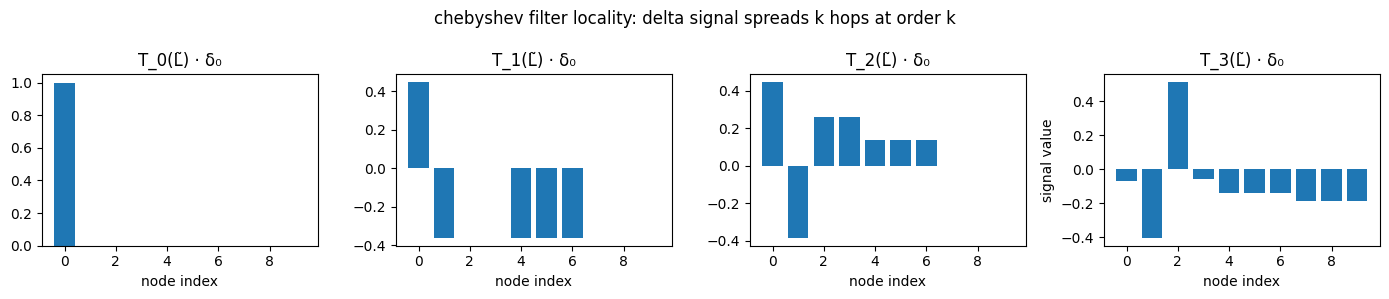

In [31]:
# cell 31 — compare filter locality: visualize T_k(L_tilde) applied to a delta signal
# a delta at node 0 should spread exactly k hops after k chebyshev steps
mol_vis = dataset[17]
N = mol_vis.num_nodes
row, col = mol_vis.edge_index

deg = torch.zeros(N)
deg.scatter_add_(0, row, torch.ones(row.shape[0]))
A = torch.zeros(N, N); A[row, col] = 1.0
L = torch.diag(deg) - A
lambda_max = torch.linalg.eigvalsh(L).max()

def L_tilde_mv(v):
    Av = torch.zeros_like(v); Av.scatter_add_(0, col.unsqueeze(-1).expand(-1,1), v[row])
    return (2.0 / lambda_max) * (deg.unsqueeze(-1)*v - Av) - v

delta = torch.zeros(N, 1); delta[0] = 1.0  # signal at node 0 only
T = [delta, L_tilde_mv(delta)]
for _ in range(2, 4):
    T.append(2 * L_tilde_mv(T[-1]) - T[-2])

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for k, (ax, Tk) in enumerate(zip(axes, T)):
    ax.bar(range(N), Tk.squeeze().numpy())
    ax.set_title(f"T_{k}(L̃) · δ₀")
    ax.set_xlabel("node index")
ax.set_ylabel("signal value")
plt.suptitle("chebyshev filter locality: delta signal spreads k hops at order k")
plt.tight_layout()
plt.savefig("chebnet_locality.png", dpi=300)
plt.show()

In [32]:
# cell 32 - wl color refinement algorithm
def wl_refinement(edge_index, num_nodes, node_labels=None, num_rounds=3):
    """
    1-wl color refinement.
    each round: color[i] = hash(color[i], sorted(color[j] for j in N(i)))
    returns: list of color dicts, one per round(including round 0)
    """
    # build adjacency list
    adj = defaultdict(list)
    ei = edge_index.numpy()
    for src, dst in zip(ei[0], ei[1]):
        adj[src].append(dst)

    # round 0: use provided labels or assign uniform color
    if node_labels is None:
        colors = {i: 1 for i in range(num_nodes)}
    else:
        colors = {i: int(node_labels[i]) for i in range(num_nodes)}

    history = [dict(colors)]

    for _ in range(num_rounds):
        new_colors = {}
        hash_map = {}
        counter = [0]

        def get_hash(signature):
            if signature not in hash_map:
                hash_map[signature] = counter[0]
                counter[0] += 1
            return hash_map[signature]

        for i in range(num_nodes):
            neighbor_colors = tuple(sorted(colors[j] for j in adj[i]))
            signature = (colors[i], neighbor_colors)
            new_colors[i] = get_hash(signature)

        colors = new_colors
        history.append(dict(colors))

    return history

# test on methane (molecule 0)
mol0 = dataset[0]
history = wl_refinement(mol0.edge_index, mol0.num_nodes)
for r, c, in enumerate(history):
    print(f"round {r}: {c}")

round 0: {0: 1, 1: 1, 2: 1, 3: 1, 4: 1}
round 1: {0: 0, 1: 1, 2: 1, 3: 1, 4: 1}
round 2: {0: 0, 1: 1, 2: 1, 3: 1, 4: 1}
round 3: {0: 0, 1: 1, 2: 1, 3: 1, 4: 1}


In [33]:
# cell 33 - construct two wl-indistinguishable graphs
# classic example: the two non-isomorphic 3-regular graphs on 6 nodes
# graph 1: K_{3, 3} (complete bipartite)
# graph 2: prism graph (triangular prism)
# both are 3-regular -> every node has degree 3 -> wl sees identical neighborhoods

def make_graph(edges, n):
    """build edge_index from undirected edge list."""
    src, dst = [], []
    for u, v in edges:
        src += [u, v]
        dst += [v, u] # bidirectional
    return torch.tensor([src, dst], dtype=torch.long), n

# k_{3, 3}: bipartite nodes {0, 1, 2} connect to {3, 4, 5}
k33_edges = [(0,3),(0,4),(0,5),(1,3),(1,4),(1,5),(2,3),(2,4),(2,5)]
ei_k33, n_k33 = make_graph(k33_edges, 6)

# prism graph: two triangles (0-1-2) and (3-4-5) connected by rungs
prism_edges = [(0,1),(1,2),(2,0),(3,4),(4,5),(5,3),(0,3),(1,4),(2,5)]
ei_prism, n_prism = make_graph(prism_edges, 6)

print("K_{3, 3} edge_index:\n", ei_k33)
print("\nPrism edge_index:\n", ei_prism)
print(f"\nboth 3-regular:\nK33 degrees={ei_k33[0].bincount().tolist()}\nprism degrees={ei_prism[0].bincount().tolist()}")

K_{3, 3} edge_index:
 tensor([[0, 3, 0, 4, 0, 5, 1, 3, 1, 4, 1, 5, 2, 3, 2, 4, 2, 5],
        [3, 0, 4, 0, 5, 0, 3, 1, 4, 1, 5, 1, 3, 2, 4, 2, 5, 2]])

Prism edge_index:
 tensor([[0, 1, 1, 2, 2, 0, 3, 4, 4, 5, 5, 3, 0, 3, 1, 4, 2, 5],
        [1, 0, 2, 1, 0, 2, 4, 3, 5, 4, 3, 5, 3, 0, 4, 1, 5, 2]])

both 3-regular:
K33 degrees=[3, 3, 3, 3, 3, 3]
prism degrees=[3, 3, 3, 3, 3, 3]


In [34]:
# cell 34 - run wl on both graphs; confirm indistinguishability
h_k33 = wl_refinement(ei_k33, n_k33, num_rounds=4)
h_prism = wl_refinement(ei_prism, n_prism, num_rounds=4)

print("round | K_{3, 3} color histogram | prism color histogram | identical?\n")
for r in range(5):
    hist_k33 = sorted(h_k33[r].values())
    hist_prism = sorted(h_prism[r].values())

    # histograms use local hash maps - compare multisets of colors symbolically
    ck = Counter(h_k33[r].values())
    cp = Counter(h_prism[r].values())
    # wl cannot distinguish iff color frequency distributions are identical
    identical = (sorted(ck.values()) == sorted(cp.values()))
    print(f"{r} | {dict(ck)} | {dict(cp)} | {identical}")

round | K_{3, 3} color histogram | prism color histogram | identical?

0 | {1: 6} | {1: 6} | True
1 | {0: 6} | {0: 6} | True
2 | {0: 6} | {0: 6} | True
3 | {0: 6} | {0: 6} | True
4 | {0: 6} | {0: 6} | True


In [35]:
# cell 35 - confirm graphs are structurally non-isomorphic
# k_{3, 3} is bipartite (no odd cycles); prism contains triangles
def has_triangle(edge_index, n):
    """returns true if graph contains any 3-cycle."""
    A = torch.zeros(n, n)
    A[edge_index[0], edge_index[1]] = 1.0
    A3 = A @ A @ A
    return A3.diagonal().any().item()

print(f"K_{{3, 3}} has triangle: {has_triangle(ei_k33, n_k33)}") # False - bipartite
print(f"Prism has triangle: {has_triangle(ei_prism, n_prism)}") # True

print("\nconclusion: graphs are non-isomorphic (different cycle structure)")
print("yet wl assigns identical color histograms at every round -> wl blind spot confirmed")

K_{3, 3} has triangle: False
Prism has triangle: True

conclusion: graphs are non-isomorphic (different cycle structure)
yet wl assigns identical color histograms at every round -> wl blind spot confirmed


In [36]:
# cell 36 - demonstrate mpnn is also blind to this difference
torch.manual_seed(42)

mpnn = MPNN(node_dim=11, edge_dim=4, hidden_dim=64, num_layers=4)
mpnn.eval()

# both graphs: uniform node features, no edge features
N = 6
x_uniform = torch.ones(N, 11) # identical atom features
e_uniform = torch.zeros(ei_k33.shape[1], 4) # identical edge features
batch = torch.zeros(N, dtype=torch.long)

with torch.no_grad():
    out_k33 = mpnn(x_uniform, ei_k33, e_uniform, batch)
    # edge attr size differs for prism (18 directed edges vs 18 - same)
    e_prism_uniform = torch.zeros(ei_prism.shape[1], 4)
    out_prism = mpnn(x_uniform, ei_prism, e_prism_uniform, batch)

print(f"MPNN output K_{{3, 3}}: {out_k33.item():.6f}")
print(f"MPNN output Prism: {out_prism.item():.6f}")
print(f"difference: {(out_k33 - out_prism).abs().item():.2e}")
print(f"\nMPNN blind spot confirmed: {'YES' if (out_k33 - out_prism).abs().item() < 1e-4 else 'output differ - check features'}")

MPNN output K_{3, 3}: 0.064199
MPNN output Prism: 0.064199
difference: 0.00e+00

MPNN blind spot confirmed: YES


In [37]:
# cell 37 - reproducibility setup and hyperparameters
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# all hyperparameters in one place - identical for both models
CONFIG = {
    "target_idx": 7,
    "hidden_dim": 64,
    "num_layers": 3,
    "cheb_k": 3,
    "lr": 1e-3,
    "batch_size": 512,
    "epochs": 128,
    "train_frac": 0.8,
    "val_frac": 0.1,
    "seed": SEED,
}

In [38]:
# cell 38 — atomic reference energies and baseline subtraction
# reference energies (eV) per atom type from QM9 atomref table
# source: qm9 dataset atomref attribute (index 7 = U0)
# pyg stores atomref directly — extract U0 column (index 7)
# atomref shape: [5, 19] → rows: [H, C, N, O, F]
# atomic numbers: [1,  6,  7,  8,  9]

atomref = dataset.atomref(TARGET_IDX) # [5, 1] reference energies
print(f"atomref for U0 (eV): {atomref.squeeze().tolist()}")
# maps: H→idx0, C→idx1, N→idx2, O→idx3, F→idx4

# one-hot columns 0-4 in x correspond to [H, C, N, O, F]
def compute_atomref_baseline(x):
    """
    subtract per-atom reference energy from U0 target.
    x: [N, 11] node features, columns 0-4 are one-hot atom type
    returns scalar baseline energy (eV)
    """
    one_hot = x[:, :5] # [N, 5]
    atom_counts = one_hot.sum(dim=0) # [5] counts per element
    atomic_nums = [1, 6, 7, 8, 9]  # H, C, N, O, F
    refs = torch.tensor([atomref[z].item() for z in atomic_nums])
    return (atom_counts * refs).sum().item()

atomref for U0 (eV): [0.0, -13.61312198638916, 0.0, 0.0, 0.0, 0.0, -1029.8631591796875, -1485.302490234375, -2042.6112060546875, -2713.48486328125, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [39]:
# cell 39 — split dataset and compute residual targets
N_total = len(dataset)
n_train = int(N_total * CONFIG["train_frac"])
n_val   = int(N_total * CONFIG["val_frac"])
n_test  = N_total - n_train - n_val

perm = torch.randperm(N_total, generator=torch.Generator().manual_seed(SEED))
train_data = dataset[perm[:n_train].tolist()]
val_data   = dataset[perm[n_train:n_train+n_val].tolist()]
test_data  = dataset[perm[n_train+n_val:].tolist()]

print(f"train: {len(train_data)}  val: {len(val_data)}  test: {len(test_data)}")

# compute residual targets on train set only — no leakage
train_residuals = torch.tensor([
    g.y[0, CONFIG["target_idx"]].item() - compute_atomref_baseline(g.x)
    for g in train_data
])

TARGET_MEAN = train_residuals.mean().item()
TARGET_STD  = train_residuals.std().item()

print(f"\nresidual U0 train mean: {TARGET_MEAN:.4f} eV")
print(f"residual U0 train std:  {TARGET_STD:.4f} eV")
print(f"\n(vs raw std ~1085 eV — reduction factor: {1085/TARGET_STD:.1f}x)")

train: 104664  val: 13083  test: 13084

residual U0 train mean: -76.1062 eV
residual U0 train std:  10.3181 eV

(vs raw std ~1085 eV — reduction factor: 105.2x)


In [40]:
# cell 40 — dataloaders
train_loader = DataLoader(train_data, batch_size=512, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_data,   batch_size=512, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_data,  batch_size=512, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)

batch = next(iter(train_loader))
print(f"batch nodes:  {batch.x.shape}")
print(f"batch edges:  {batch.edge_index.shape}")
print(f"batch target: {batch.y[:, CONFIG['target_idx']].shape}")

batch nodes:  torch.Size([9143, 11])
batch edges:  torch.Size([2, 18916])
batch target: torch.Size([512])


In [41]:
# cell 41 — training and evaluation with atomref baseline
def get_residual_target(batch):
    """
    compute residual U0 = raw U0 - sum of atomic reference energies.
    operates on a batched pyg batch object.
    """
    raw = batch.y[:, CONFIG["target_idx"]] # [B]

    # compute per-graph atomref baseline using batch assignment
    num_graphs = batch.num_graphs
    one_hot = batch.x[:, :5] # [N_total, 5]
    baseline = torch.zeros(num_graphs, device=batch.x.device)
    for g_idx in range(num_graphs):
        mask = batch.batch == g_idx
        counts = one_hot[mask].sum(dim=0) # [5]
        atomic_nums = [1, 6, 7, 8, 9]
        refs = torch.tensor([atomref[z].item() for z in atomic_nums], device=batch.x.device)
        baseline[g_idx] = (counts * refs).sum()

    return raw - baseline # [B] residual


def train_epoch(model, loader, optimizer, device):
    """one training epoch; returns MAE in eV on residual target."""
    model.train()
    total_mae = 0.0
    for batch in loader:
        batch = batch.to(device)
        y_res = get_residual_target(batch)
        y_norm = (y_res - TARGET_MEAN) / TARGET_STD

        optimizer.zero_grad()
        pred = model(batch.x, batch.edge_index, batch.edge_attr,
                     batch.batch).squeeze(-1)
        loss = (pred - y_norm).abs().mean()
        loss.backward()
        optimizer.step()
        total_mae += loss.item() * batch.num_graphs

    return (total_mae / len(loader.dataset)) * TARGET_STD # eV


@torch.no_grad()
def evaluate(model, loader, device):
    """returns MAE in eV on residual target."""
    model.eval()
    total_mae = 0.0
    for batch in loader:
        batch = batch.to(device)
        y_res = get_residual_target(batch)
        y_norm = (y_res - TARGET_MEAN) / TARGET_STD
        pred = model(batch.x, batch.edge_index, batch.edge_attr,
                     batch.batch).squeeze(-1)
        total_mae += (pred - y_norm).abs().sum().item()

    return (total_mae / len(loader.dataset)) * TARGET_STD # eV

In [42]:
# cell 42 — reinstantiate models with fixed seed
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

mpnn = MPNN(node_dim=11, edge_dim=4, hidden_dim=CONFIG["hidden_dim"], num_layers=CONFIG["num_layers"]).to(device)
chebnet = ChebNet(node_dim=11, hidden_dim=CONFIG["hidden_dim"], num_layers=CONFIG["num_layers"], K=CONFIG["cheb_k"]).to(device)

print(f"\nMPNN parameters: {sum(p.numel() for p in mpnn.parameters()):,}")
print(f"ChebNet parameters: {sum(p.numel() for p in chebnet.parameters()):,}")

device: cuda

MPNN parameters: 67,777
ChebNet parameters: 42,049


In [43]:
# cell 43 — training loop
def run_training(model, name):
    optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])
    scheduler = ReduceLROnPlateau(optimizer, patience=10, factor=0.5, min_lr=1e-5)
    history = {"train_mae": [], "val_mae": []}
    best_val = float("inf")

    pbar = tqdm(range(1, CONFIG["epochs"] + 1), desc=name)
    for epoch in pbar:
        train_mae = train_epoch(model, train_loader, optimizer, device)
        val_mae   = evaluate(model, val_loader, device)
        scheduler.step(val_mae)

        history["train_mae"].append(train_mae)
        history["val_mae"].append(val_mae)

        if val_mae < best_val:
            best_val = val_mae
            torch.save(model.state_dict(), f"best_{name}.pt")

        pbar.set_postfix({
            "train": f"{train_mae:.4f}",
            "val":   f"{val_mae:.4f}",
            "lr":    f"{optimizer.param_groups[0]['lr']:.2e}"
        })

    return history

print("training MPNN...")
hist_mpnn = run_training(mpnn, "mpnn")

print("\ntraining ChebNet...")
hist_cheb = run_training(chebnet, "chebnet")

training MPNN...


mpnn: 100%|██████████| 128/128 [1:06:15<00:00, 31.06s/it, train=1.4559, val=1.4788, lr=1.00e-03]



training ChebNet...


chebnet: 100%|██████████| 128/128 [1:05:39<00:00, 30.77s/it, train=1.7978, val=1.8510, lr=1.00e-03]


In [44]:
# cell 44 — test evaluation
mpnn.load_state_dict(torch.load("best_mpnn.pt"))
chebnet.load_state_dict(torch.load("best_chebnet.pt"))

test_mae_mpnn = evaluate(mpnn,    test_loader, device)
test_mae_cheb = evaluate(chebnet, test_loader, device)

print(f"{'Model':<12} {'Test MAE (eV)':>14} {'Normalized MAE':>16}")
print(f"{'MPNN':<12} {test_mae_mpnn:>14.4f} {test_mae_mpnn/TARGET_STD:>16.4f}")
print(f"{'ChebNet':<12} {test_mae_cheb:>14.4f} {test_mae_cheb/TARGET_STD:>16.4f}")
print(f"\n(residual target std: {TARGET_STD:.4f} eV)")

Model         Test MAE (eV)   Normalized MAE
MPNN                 1.4392           0.1395
ChebNet              1.7810           0.1726

(residual target std: 10.3181 eV)


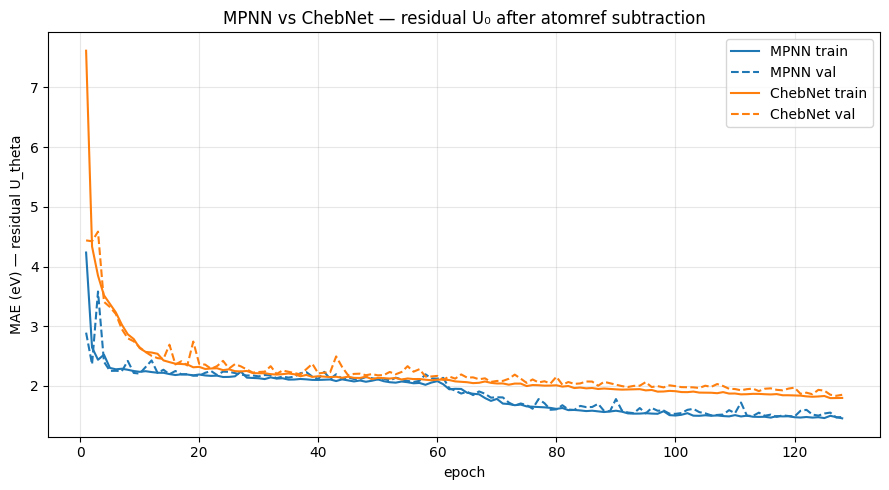

In [45]:
# cell 45 — training curves
epochs = range(1, CONFIG["epochs"] + 1)
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(epochs, hist_mpnn["train_mae"], "C0-",  label="MPNN train")
ax.plot(epochs, hist_mpnn["val_mae"], "C0--", label="MPNN val")
ax.plot(epochs, hist_cheb["train_mae"], "C1-",  label="ChebNet train")
ax.plot(epochs, hist_cheb["val_mae"], "C1--", label="ChebNet val")

ax.set_xlabel("epoch")
ax.set_ylabel("MAE (eV) — residual U_theta")
ax.set_title("MPNN vs ChebNet — residual U₀ after atomref subtraction")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=300)
plt.show()